# 🎵 스펙트로그램 기반 CNN 분류 (Spectrogram-based CNN Classification)

이 노트북에서는 소리 신호를 2차원 이미지로 표현하여 합성곱 신경망으로 상태를 분류합니다.

## 📋 목차
1. **방법 1**: 로그 멜 스펙트로그램 + 미분값 채널 → 2개 합성곱 계층 + 2개 전연결 계층
2. **방법 2**: 데이터 증강 + 로그 멜 스펙트로그램 → 3개 합성곱 계층 + 2개 전연결 계층
3. **방법 3**: 스펙트로그램, MFCC, CRP 비교 → 다양한 CNN 모델 비교
4. **성능 비교**: 모든 방법의 분류 정확도 비교


In [1]:
# ============================================================
# 필수 라이브러리 임포트
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from collections import Counter

# 공통 유틸리티
from utils import setup_plotting, get_data_dir, get_state_mapping, get_state_names

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import librosa

# 머신러닝
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 프로젝트 모듈
from app.ml.features.extractor import AudioFeatureExtractor, AudioConfig
from app.ml.features.augmentation import AudioAugmentor, AugmentationConfig
from app.ml.training.trainer import Trainer, create_optimizer, create_scheduler

# 시각화 설정
setup_plotting()

# 디바이스 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ 라이브러리 로드 완료!")
print(f"🖥️ Device: {device}")


✅ 라이브러리 로드 완료!
🖥️ Device: cpu


---
## 1. 데이터 로드 (combined 폴더 제외)


In [2]:
# ============================================================
# 데이터 경로 수집 (combined 폴더 제외)
# ============================================================

data_dir = get_data_dir()
augmented_dir = data_dir / 'augmented'

# 파일 경로와 레이블 수집
all_files = []
all_states = []

# 상태 매핑
state_mapping = get_state_mapping()
state_names = get_state_names()

print("📂 데이터 로드 중... (combined 폴더 제외)")

# 원본 데이터 수집
for state_dir in sorted(data_dir.iterdir()):
    if not state_dir.is_dir() or state_dir.name == 'augmented':
        continue
    
    state_name = state_dir.name
    state_idx = state_mapping.get(state_name, -1)
    
    if state_idx == -1:
        continue
    
    for problem_dir in sorted(state_dir.iterdir()):
        if not problem_dir.is_dir():
            continue
        
        problem_name = problem_dir.name
        
        # ⚠️ combined 폴더 제외
        if problem_name == 'combined':
            continue
        
        # WAV 파일 수집
        wav_files = list(problem_dir.glob('*.wav'))
        for f in wav_files:
            all_files.append(f)
            all_states.append(state_idx)
        
        # 하위 폴더 확인 (combined 제외)
        for sub_dir in problem_dir.iterdir():
            if sub_dir.is_dir() and sub_dir.name != 'combined':
                sub_files = list(sub_dir.glob('*.wav'))
                for f in sub_files:
                    all_files.append(f)
                    all_states.append(state_idx)

original_count = len(all_files)
print(f"   원본 샘플: {original_count}개")

# 증강 데이터 수집
if augmented_dir.exists():
    for state_dir in sorted(augmented_dir.iterdir()):
        if not state_dir.is_dir():
            continue
        
        state_name = state_dir.name
        state_idx = state_mapping.get(state_name, -1)
        
        if state_idx == -1:
            continue
        
        for problem_dir in sorted(state_dir.iterdir()):
            if not problem_dir.is_dir():
                continue
            
            problem_name = problem_dir.name
            
            # ⚠️ combined 폴더 제외
            if problem_name == 'combined':
                continue
            
            # 증강 WAV 파일 수집
            aug_files = list(problem_dir.glob('*.wav'))
            for f in aug_files:
                all_files.append(f)
                all_states.append(state_idx)
            
            # 하위 폴더 확인 (combined 제외)
            for sub_dir in problem_dir.iterdir():
                if sub_dir.is_dir() and sub_dir.name != 'combined':
                    sub_files = list(sub_dir.glob('*.wav'))
                    for f in sub_files:
                        all_files.append(f)
                        all_states.append(state_idx)

augmented_count = len(all_files) - original_count
print(f"   증강 샘플: {augmented_count}개")

print("\n" + "=" * 50)
print(f"📊 총 데이터: {len(all_files)}개 (combined 제외)")
print("=" * 50)

# 상태별 분포 확인
state_counts = Counter(all_states)
print("\n📊 상태별 분포:")
for idx, name in enumerate(state_names):
    print(f"  [{idx}] {name}: {state_counts[idx]}개")


📂 데이터 로드 중... (combined 폴더 제외)
   원본 샘플: 949개
   증강 샘플: 1883개

📊 총 데이터: 2832개 (combined 제외)

📊 상태별 분포:
  [0] braking: 612개
  [1] idle: 1320개
  [2] startup: 900개


---
## 2. 방법 1: 로그 멜 스펙트로그램 + 미분값 채널 → 2개 합성곱 계층


In [3]:
# ============================================================
# 피처 추출기 초기화
# ============================================================

audio_config = AudioConfig(
    sample_rate=22050,
    duration=5.0,
    n_mels=128,
    n_mfcc=40,
    n_fft=2048,
    hop_length=512
)

feature_extractor = AudioFeatureExtractor(config=audio_config)
print("✅ 피처 추출기 초기화 완료!")


✅ 피처 추출기 초기화 완료!


In [4]:
# ============================================================
# 방법 1: 로그 멜 스펙트로그램 + 미분값 채널 데이터셋
# ============================================================

from typing import Optional

class SpectrogramDeltaDataset(Dataset):
    """
    로그 멜 스펙트로그램 + 미분값(Delta)을 채널로 추가한 데이터셋
    """
    
    def __init__(
        self,
        file_paths: list,
        labels: list,
        feature_extractor: AudioFeatureExtractor,
        augmentor: Optional[AudioAugmentor] = None,
        apply_augment: bool = False,
        is_training: bool = True,
        target_shape: tuple = (128, 216)
    ):
        self.file_paths = file_paths
        self.labels = labels
        self.feature_extractor = feature_extractor
        self.augmentor = augmentor
        self.apply_augment = apply_augment
        self.is_training = is_training
        self.target_shape = target_shape
        
    def __len__(self):
        return len(self.file_paths)
    
    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        label = self.labels[idx]
        
        # 오디오 로드
        y, sr = self.feature_extractor.load_audio(str(file_path))
        
        # 1. 로그 멜 스펙트로그램
        mel_spec = self.feature_extractor.extract_mel_spectrogram(y, sr, to_db=True)
        mel_spec = self.feature_extractor._resize_spectrogram(mel_spec, self.target_shape)
        
        # 2. 미분값 (Delta) 계산 - 시간 축으로 미분
        delta = np.diff(mel_spec, axis=1)  # 시간 축으로 미분
        # 차원 맞추기 (마지막 시간 프레임 제거)
        delta = np.pad(delta, ((0, 0), (0, 1)), mode='edge')  # 마지막 프레임 복제
        
        # 정규화
        mel_spec = (mel_spec - mel_spec.mean()) / (mel_spec.std() + 1e-8)
        delta = (delta - delta.mean()) / (delta.std() + 1e-8)
        
        # 2채널로 결합: [로그 멜 스펙트로그램, 미분값]
        features = np.stack([mel_spec, delta], axis=0)  # (2, 128, 216)
        
        # 데이터 증강 (학습 시에만)
        if self.is_training and self.apply_augment and self.augmentor is not None:
            for c in range(features.shape[0]):
                features[c] = self.augmentor.spec_augment(
                    features[c], num_freq_masks=2, num_time_masks=2,
                    freq_mask_param=15, time_mask_param=35
                )
        
        features_tensor = torch.FloatTensor(features)
        label_tensor = torch.LongTensor([label])[0]
        
        return features_tensor, label_tensor

print("✅ SpectrogramDeltaDataset 클래스 정의 완료!")


✅ SpectrogramDeltaDataset 클래스 정의 완료!


In [5]:
# ============================================================
# 방법 1: 2개 합성곱 계층 + 2개 전연결 계층 CNN 모델
# ============================================================

class SimpleCNN2Layer(nn.Module):
    """
    2개 합성곱 계층 + 2개 전연결 계층으로 구성된 CNN
    로그 멜 스펙트로그램 + 미분값 채널 입력
    """
    
    def __init__(
        self,
        num_classes: int,
        in_channels: int = 2,  # 로그 멜 + 미분값
        base_channels: int = 32,
        dropout: float = 0.3
    ):
        super().__init__()
        
        # 합성곱 계층 1
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels, base_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(base_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(dropout / 2)
        )
        
        # 합성곱 계층 2
        self.conv2 = nn.Sequential(
            nn.Conv2d(base_channels, base_channels * 2, kernel_size=3, padding=1),
            nn.BatchNorm2d(base_channels * 2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(dropout / 2)
        )
        
        # Global Average Pooling
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        
        # 전연결 계층 1
        self.fc1 = nn.Sequential(
            nn.Linear(base_channels * 2, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout)
        )
        
        # 전연결 계층 2 (출력)
        self.fc2 = nn.Linear(128, num_classes)
        
    def forward(self, x):
        # x: (batch, 2, 128, 216)
        x = self.conv1(x)  # (batch, 32, 64, 108)
        x = self.conv2(x)  # (batch, 64, 32, 54)
        x = self.global_pool(x)  # (batch, 64, 1, 1)
        x = x.view(x.size(0), -1)  # (batch, 64)
        x = self.fc1(x)  # (batch, 128)
        x = self.fc2(x)  # (batch, num_classes)
        return x

print("✅ SimpleCNN2Layer 모델 정의 완료!")


✅ SimpleCNN2Layer 모델 정의 완료!


In [6]:
# ============================================================
# 방법 1: 데이터 준비 및 학습
# ============================================================

# 데이터 분할
X_train, X_temp, y_train, y_temp = train_test_split(
    all_files, all_states,
    test_size=0.3,
    stratify=all_states,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

print("📊 데이터 분할:")
print(f"  • 학습 셋: {len(X_train)}개")
print(f"  • 검증 셋: {len(X_val)}개")
print(f"  • 테스트 셋: {len(X_test)}개")

# 증강기
aug_config = AugmentationConfig()
augmentor = AudioAugmentor(config=aug_config)

# 데이터셋 생성
BATCH_SIZE = 16

train_dataset_method1 = SpectrogramDeltaDataset(
    file_paths=X_train, labels=y_train,
    feature_extractor=feature_extractor,
    augmentor=augmentor, apply_augment=True, is_training=True
)

val_dataset_method1 = SpectrogramDeltaDataset(
    file_paths=X_val, labels=y_val,
    feature_extractor=feature_extractor,
    augmentor=None, apply_augment=False, is_training=False
)

test_dataset_method1 = SpectrogramDeltaDataset(
    file_paths=X_test, labels=y_test,
    feature_extractor=feature_extractor,
    augmentor=None, apply_augment=False, is_training=False
)

train_loader_method1 = DataLoader(train_dataset_method1, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader_method1 = DataLoader(val_dataset_method1, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader_method1 = DataLoader(test_dataset_method1, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"\n✅ DataLoader 생성 완료!")


📊 데이터 분할:
  • 학습 셋: 1982개
  • 검증 셋: 425개
  • 테스트 셋: 425개

✅ DataLoader 생성 완료!


In [7]:
# ============================================================
# 방법 1: 모델 생성 및 학습
# ============================================================

NUM_STATES = 3

# 모델 생성
model_method1 = SimpleCNN2Layer(
    num_classes=NUM_STATES,
    in_channels=2,  # 로그 멜 + 미분값
    base_channels=32,
    dropout=0.3
)
model_method1 = model_method1.to(device)

print("🏗️ 방법 1 모델 구조:")
print(f"   입력: 로그 멜 스펙트로그램 + 미분값 (2채널)")
print(f"   구조: 2개 합성곱 계층 + 2개 전연결 계층")
total_params = sum(p.numel() for p in model_method1.parameters())
print(f"   파라미터: {total_params:,}")

# 클래스 가중치
state_counts_list = [state_counts[i] for i in range(NUM_STATES)]
class_weights = 1.0 / torch.FloatTensor(state_counts_list)
class_weights = class_weights / class_weights.sum() * NUM_STATES

# 학습 설정
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = create_optimizer(model_method1, 'adamw', lr=1e-3, weight_decay=0.01)
scheduler = create_scheduler(optimizer, 'cosine', epochs=20)

# 체크포인트 디렉토리
checkpoint_dir = Path('../checkpoints')
checkpoint_dir.mkdir(exist_ok=True)

# Trainer
trainer_method1 = Trainer(
    model=model_method1,
    train_loader=train_loader_method1,
    val_loader=val_loader_method1,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=str(device),
    save_dir=str(checkpoint_dir),
    experiment_name='method1_spectrogram_delta_2conv',
    use_amp=(device.type == 'cuda')
)

# 학습
print("\n🚀 방법 1 모델 학습 시작!")
print("=" * 60)

history_method1 = trainer_method1.train(
    epochs=20,
    early_stopping_patience=7,
    save_best=True,
    verbose=True
)

print("\n✅ 방법 1 모델 학습 완료!")


🏗️ 방법 1 모델 구조:
   입력: 로그 멜 스펙트로그램 + 미분값 (2채널)
   구조: 2개 합성곱 계층 + 2개 전연결 계층
   파라미터: 28,259

🚀 방법 1 모델 학습 시작!

Starting training: method1_spectrogram_delta_2conv
Device: cpu
Total epochs: 20



Training: 100%|██████████| 124/124 [01:18<00:00,  1.59it/s, loss=1.0892, acc=38.75%]


Epoch [1/20]
  Train Loss: 1.1109 | Train Acc: 38.75%
  Val Loss: 0.9750 | Val Acc: 45.41%
  LR: 0.001000
  ✓ Best model saved!



Training: 100%|██████████| 124/124 [01:04<00:00,  1.93it/s, loss=1.0293, acc=46.62%]


Epoch [2/20]
  Train Loss: 1.0331 | Train Acc: 46.62%
  Val Loss: 0.8562 | Val Acc: 63.29%
  LR: 0.000994
  ✓ Best model saved!



...

Epoch [18/20]
  Train Loss: 0.7632 | Train Acc: 61.35%
  Val Loss: 0.6353 | Val Acc: 71.53%
  LR: 0.000055



Training: 100%|██████████| 124/124 [01:08<00:00,  1.82it/s, loss=0.4704, acc=61.81%]


Epoch [19/20]
  Train Loss: 0.7814 | Train Acc: 61.81%
  Val Loss: 0.6441 | Val Acc: 71.76%
  LR: 0.000025



Training: 100%|██████████| 124/124 [01:07<00:00,  1.84it/s, loss=0.8680, acc=63.02%]


Epoch [20/20]
  Train Loss: 0.7761 | Train Acc: 63.02%
  Val Loss: 0.6318 | Val Acc: 71.76%
  LR: 0.000007


✅ 방법 1 모델 학습 완료!


✅ Best 모델 로드 완료!


Evaluating 방법 1: 로그 멜 + 미분값 (2개 합성곱 계층): 100%|██████████| 27/27 [00:11<00:00,  2.33it/s]



📊 방법 1: 로그 멜 + 미분값 (2개 합성곱 계층) 테스트 결과
정확도: 71.06%

📋 Classification Report:
              precision    recall  f1-score   support

     braking       0.44      0.22      0.29        92
        idle       0.69      0.81      0.75       198
     startup       0.82      0.90      0.86       135

    accuracy                           0.71       425
   macro avg       0.65      0.64      0.63       425
weighted avg       0.68      0.71      0.68       425



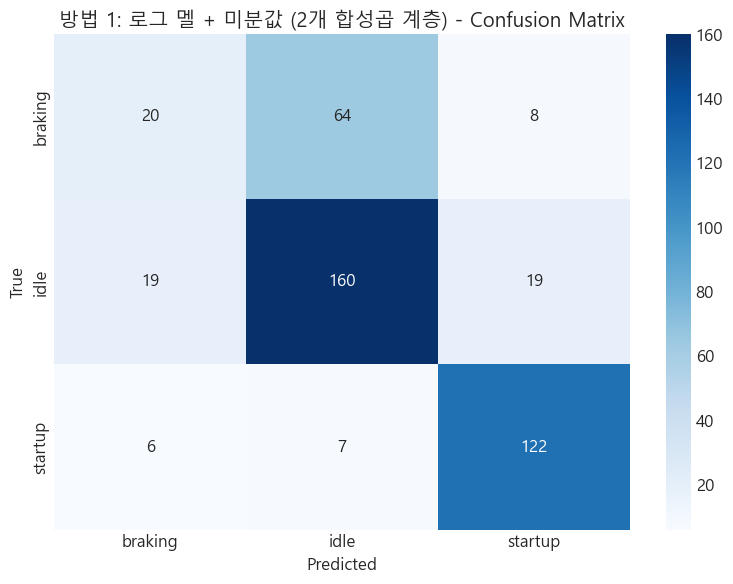

In [8]:
# ============================================================
# 방법 1: 모델 평가
# ============================================================

def evaluate_model(model, test_loader, device, class_names, model_name="Model"):
    """모델 평가"""
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch_x, batch_y in tqdm(test_loader, desc=f"Evaluating {model_name}"):
            batch_x = batch_x.to(device)
            outputs = model(batch_x)
            _, preds = outputs.max(1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch_y.numpy())
    
    accuracy = 100 * sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
    
    print(f"\n{'='*60}")
    print(f"📊 {model_name} 테스트 결과")
    print(f"{'='*60}")
    print(f"정확도: {accuracy:.2f}%")
    
    print("\n📋 Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names, zero_division='warn'))
    
    # 혼동 행렬
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'{model_name} - Confusion Matrix')
    plt.tight_layout()
    plt.show()
    
    return accuracy, all_preds, all_labels

# Best 모델 로드
best_path_method1 = checkpoint_dir / 'method1_spectrogram_delta_2conv_best_model.pt'
if best_path_method1.exists():
    checkpoint = torch.load(best_path_method1, map_location=device)
    model_method1.load_state_dict(checkpoint['model_state_dict'])
    print(f"✅ Best 모델 로드 완료!")

# 평가
acc_method1, _, _ = evaluate_model(
    model_method1, test_loader_method1, device, state_names, 
    "방법 1: 로그 멜 + 미분값 (2개 합성곱 계층)"
)


In [9]:
# ============================================================
# 방법 2: 로그 멜 스펙트로그램 데이터셋 (데이터 증강 적용)
# ============================================================

class SpectrogramDataset(Dataset):
    """
    로그 멜 스펙트로그램 데이터셋 (데이터 증강 적용)
    """
    
    def __init__(
        self,
        file_paths: list,
        labels: list,
        feature_extractor: AudioFeatureExtractor,
        augmentor: Optional[AudioAugmentor] = None,
        apply_augment: bool = False,
        is_training: bool = True,
        target_shape: tuple = (128, 216)
    ):
        self.file_paths = file_paths
        self.labels = labels
        self.feature_extractor = feature_extractor
        self.augmentor = augmentor
        self.apply_augment = apply_augment
        self.is_training = is_training
        self.target_shape = target_shape
        
    def __len__(self):
        return len(self.file_paths)
    
    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        label = self.labels[idx]
        
        # 오디오 로드
        y, sr = self.feature_extractor.load_audio(str(file_path))
        
        # 로그 멜 스펙트로그램
        mel_spec = self.feature_extractor.extract_mel_spectrogram(y, sr, to_db=True)
        mel_spec = self.feature_extractor._resize_spectrogram(mel_spec, self.target_shape)
        
        # 정규화
        mel_spec = (mel_spec - mel_spec.mean()) / (mel_spec.std() + 1e-8)
        
        # 채널 차원 추가
        features = mel_spec[np.newaxis, :, :]  # (1, 128, 216)
        
        # 데이터 증강 (학습 시에만)
        if self.is_training and self.apply_augment and self.augmentor is not None:
            features[0] = self.augmentor.spec_augment(
                features[0], num_freq_masks=2, num_time_masks=2,
                freq_mask_param=15, time_mask_param=35
            )
        
        features_tensor = torch.FloatTensor(features)
        label_tensor = torch.LongTensor([label])[0]
        
        return features_tensor, label_tensor

print("✅ SpectrogramDataset 클래스 정의 완료!")


✅ SpectrogramDataset 클래스 정의 완료!


In [10]:
# ============================================================
# 방법 2: 3개 합성곱 계층 + 2개 전연결 계층 CNN 모델
# ============================================================

class SimpleCNN3Layer(nn.Module):
    """
    3개 합성곱 계층 + 2개 전연결 계층으로 구성된 CNN
    로그 멜 스펙트로그램 입력
    """
    
    def __init__(
        self,
        num_classes: int,
        in_channels: int = 1,
        base_channels: int = 32,
        dropout: float = 0.3
    ):
        super().__init__()
        
        # 합성곱 계층 1
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels, base_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(base_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(dropout / 3)
        )
        
        # 합성곱 계층 2
        self.conv2 = nn.Sequential(
            nn.Conv2d(base_channels, base_channels * 2, kernel_size=3, padding=1),
            nn.BatchNorm2d(base_channels * 2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(dropout / 3)
        )
        
        # 합성곱 계층 3
        self.conv3 = nn.Sequential(
            nn.Conv2d(base_channels * 2, base_channels * 4, kernel_size=3, padding=1),
            nn.BatchNorm2d(base_channels * 4),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(dropout / 3)
        )
        
        # Global Average Pooling
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        
        # 전연결 계층 1
        self.fc1 = nn.Sequential(
            nn.Linear(base_channels * 4, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout)
        )
        
        # 전연결 계층 2 (출력)
        self.fc2 = nn.Linear(128, num_classes)
        
    def forward(self, x):
        # x: (batch, 1, 128, 216)
        x = self.conv1(x)  # (batch, 32, 64, 108)
        x = self.conv2(x)  # (batch, 64, 32, 54)
        x = self.conv3(x)  # (batch, 128, 16, 27)
        x = self.global_pool(x)  # (batch, 128, 1, 1)
        x = x.view(x.size(0), -1)  # (batch, 128)
        x = self.fc1(x)  # (batch, 128)
        x = self.fc2(x)  # (batch, num_classes)
        return x

print("✅ SimpleCNN3Layer 모델 정의 완료!")


✅ SimpleCNN3Layer 모델 정의 완료!


In [11]:
# ============================================================
# 방법 2: 데이터 준비 및 학습
# ============================================================

# 데이터셋 생성 (데이터 증강 적용)
train_dataset_method2 = SpectrogramDataset(
    file_paths=X_train, labels=y_train,
    feature_extractor=feature_extractor,
    augmentor=augmentor, apply_augment=True, is_training=True
)

val_dataset_method2 = SpectrogramDataset(
    file_paths=X_val, labels=y_val,
    feature_extractor=feature_extractor,
    augmentor=None, apply_augment=False, is_training=False
)

test_dataset_method2 = SpectrogramDataset(
    file_paths=X_test, labels=y_test,
    feature_extractor=feature_extractor,
    augmentor=None, apply_augment=False, is_training=False
)

train_loader_method2 = DataLoader(train_dataset_method2, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader_method2 = DataLoader(val_dataset_method2, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader_method2 = DataLoader(test_dataset_method2, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"✅ 방법 2 DataLoader 생성 완료!")

# 모델 생성
model_method2 = SimpleCNN3Layer(
    num_classes=NUM_STATES,
    in_channels=1,
    base_channels=32,
    dropout=0.3
)
model_method2 = model_method2.to(device)

print("\n🏗️ 방법 2 모델 구조:")
print(f"   입력: 로그 멜 스펙트로그램 (1채널)")
print(f"   구조: 3개 합성곱 계층 + 2개 전연결 계층")
print(f"   데이터 증강: SpecAugment 적용")
total_params = sum(p.numel() for p in model_method2.parameters())
print(f"   파라미터: {total_params:,}")

# 학습 설정
optimizer = create_optimizer(model_method2, 'adamw', lr=1e-3, weight_decay=0.01)
scheduler = create_scheduler(optimizer, 'cosine', epochs=20)

# Trainer
trainer_method2 = Trainer(
    model=model_method2,
    train_loader=train_loader_method2,
    val_loader=val_loader_method2,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=str(device),
    save_dir=str(checkpoint_dir),
    experiment_name='method2_spectrogram_3conv_aug',
    use_amp=(device.type == 'cuda')
)

# 학습
print("\n🚀 방법 2 모델 학습 시작!")
print("=" * 60)

history_method2 = trainer_method2.train(
    epochs=20,
    early_stopping_patience=7,
    save_best=True,
    verbose=True
)

print("\n✅ 방법 2 모델 학습 완료!")


✅ 방법 2 DataLoader 생성 완료!

🏗️ 방법 2 모델 구조:
   입력: 로그 멜 스펙트로그램 (1채널)
   구조: 3개 합성곱 계층 + 2개 전연결 계층
   데이터 증강: SpecAugment 적용
   파라미터: 110,275

🚀 방법 2 모델 학습 시작!

Starting training: method2_spectrogram_3conv_aug
Device: cpu
Total epochs: 20



Training: 100%|██████████| 124/124 [01:15<00:00,  1.65it/s, loss=0.8066, acc=42.63%]


Epoch [1/20]
  Train Loss: 1.0727 | Train Acc: 42.63%
  Val Loss: 0.9810 | Val Acc: 42.35%
  LR: 0.001000
  ✓ Best model saved!



Training: 100%|██████████| 124/124 [01:16<00:00,  1.61it/s, loss=0.8943, acc=48.03%]


Epoch [2/20]
  Train Loss: 1.0082 | Train Acc: 48.03%
  Val Loss: 0.8714 | Val Acc: 66.12%
  LR: 0.000994
  ✓ Best model saved!



...

Epoch [18/20]
  Train Loss: 0.7797 | Train Acc: 63.32%
  Val Loss: 0.6459 | Val Acc: 69.65%
  LR: 0.000055



Training: 100%|██████████| 124/124 [01:19<00:00,  1.57it/s, loss=0.7025, acc=63.82%]


Epoch [19/20]
  Train Loss: 0.7520 | Train Acc: 63.82%
  Val Loss: 0.6175 | Val Acc: 77.65%
  LR: 0.000025



Training: 100%|██████████| 124/124 [01:19<00:00,  1.57it/s, loss=0.8201, acc=63.62%]


Epoch [20/20]
  Train Loss: 0.7597 | Train Acc: 63.62%
  Val Loss: 0.6111 | Val Acc: 76.94%
  LR: 0.000007

Early stopping triggered at epoch 20

✅ 방법 2 모델 학습 완료!


✅ Best 모델 로드 완료!


Evaluating 방법 2: 로그 멜 스펙트로그램 + 데이터 증강 (3개 합성곱 계층): 100%|██████████| 27/27 [00:10<00:00,  2.67it/s]



📊 방법 2: 로그 멜 스펙트로그램 + 데이터 증강 (3개 합성곱 계층) 테스트 결과
정확도: 77.41%

📋 Classification Report:
              precision    recall  f1-score   support

     braking       0.72      0.39      0.51        92
        idle       0.73      0.88      0.80       198
     startup       0.88      0.88      0.88       135

    accuracy                           0.77       425
   macro avg       0.77      0.72      0.73       425
weighted avg       0.77      0.77      0.76       425



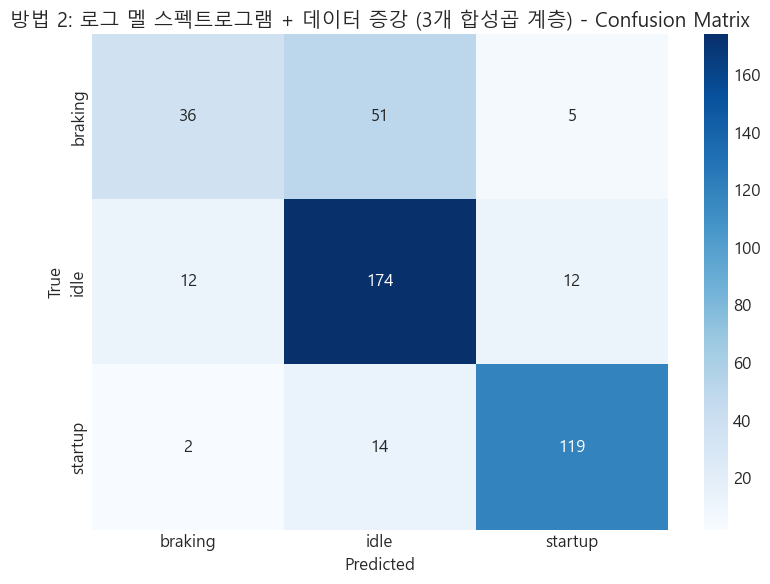

In [12]:
# ============================================================
# 방법 2: 모델 평가
# ============================================================

# Best 모델 로드
best_path_method2 = checkpoint_dir / 'method2_spectrogram_3conv_aug_best_model.pt'
if best_path_method2.exists():
    checkpoint = torch.load(best_path_method2, map_location=device)
    model_method2.load_state_dict(checkpoint['model_state_dict'])
    print(f"✅ Best 모델 로드 완료!")

# 평가
acc_method2, _, _ = evaluate_model(
    model_method2, test_loader_method2, device, state_names,
    "방법 2: 로그 멜 스펙트로그램 + 데이터 증강 (3개 합성곱 계층)"
)


---
## 4. 방법 3: 다양한 피처 비교 (스펙트로그램, MFCC, CRP)


In [13]:
# ============================================================
# 방법 3: 다양한 피처 데이터셋 (스펙트로그램, MFCC, CRP)
# ============================================================

class MultiFeatureDataset(Dataset):
    """
    다양한 피처를 지원하는 데이터셋
    - 스펙트로그램 (Mel Spectrogram)
    - MFCC
    - CRP (Chroma)
    """
    
    def __init__(
        self,
        file_paths: list,
        labels: list,
        feature_extractor: AudioFeatureExtractor,
        feature_type: str = 'spectrogram',  # 'spectrogram', 'mfcc', 'chroma'
        augmentor: Optional[AudioAugmentor] = None,
        apply_augment: bool = False,
        is_training: bool = True,
        target_shape: tuple = (128, 216)
    ):
        self.file_paths = file_paths
        self.labels = labels
        self.feature_extractor = feature_extractor
        self.feature_type = feature_type
        self.augmentor = augmentor
        self.apply_augment = apply_augment
        self.is_training = is_training
        self.target_shape = target_shape
        
    def __len__(self):
        return len(self.file_paths)
    
    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        label = self.labels[idx]
        
        # 오디오 로드
        y, sr = self.feature_extractor.load_audio(str(file_path))
        
        # 피처 타입에 따라 추출
        if self.feature_type == 'spectrogram':
            features = self.feature_extractor.extract_mel_spectrogram(y, sr, to_db=True)
        elif self.feature_type == 'mfcc':
            features = self.feature_extractor.extract_mfcc(y, sr, include_delta=False)
        elif self.feature_type == 'chroma':
            features = self.feature_extractor.extract_chroma(y, sr)
        else:
            raise ValueError(f"Unknown feature type: {self.feature_type}")
        
        # 크기 조정
        features = self.feature_extractor._resize_spectrogram(features, self.target_shape)
        
        # 정규화
        features = (features - features.mean()) / (features.std() + 1e-8)
        
        # 채널 차원 추가
        features = features[np.newaxis, :, :]  # (1, freq, time)
        
        # 데이터 증강
        if self.is_training and self.apply_augment and self.augmentor is not None:
            features[0] = self.augmentor.spec_augment(
                features[0], num_freq_masks=2, num_time_masks=2,
                freq_mask_param=15, time_mask_param=35
            )
        
        features_tensor = torch.FloatTensor(features)
        label_tensor = torch.LongTensor([label])[0]
        
        return features_tensor, label_tensor

print("✅ MultiFeatureDataset 클래스 정의 완료!")


✅ MultiFeatureDataset 클래스 정의 완료!



🔬 스펙트로그램 피처로 모델 학습

🚀 스펙트로그램 피처 모델 학습 시작!

Starting training: method3_spectrogram_3conv
Device: cpu
Total epochs: 20



Training: 100%|██████████| 124/124 [01:16<00:00,  1.63it/s, loss=0.9971, acc=40.62%]


Epoch [1/20]
  Train Loss: 1.0901 | Train Acc: 40.62%
  Val Loss: 1.0198 | Val Acc: 47.76%
  LR: 0.001000
  ✓ Best model saved!



Training: 100%|██████████| 124/124 [01:16<00:00,  1.63it/s, loss=0.9674, acc=47.33%]


Epoch [2/20]
  Train Loss: 1.0077 | Train Acc: 47.33%
  Val Loss: 1.0393 | Val Acc: 48.47%
  LR: 0.000994



...

Epoch [19/20]
  Train Loss: 0.7531 | Train Acc: 64.28%
  Val Loss: 0.7251 | Val Acc: 72.47%
  LR: 0.000025



Training: 100%|██████████| 124/124 [01:23<00:00,  1.48it/s, loss=0.6298, acc=64.18%]


Epoch [20/20]
  Train Loss: 0.7639 | Train Acc: 64.18%
  Val Loss: 0.6820 | Val Acc: 74.35%
  LR: 0.000007



Evaluating 방법 3: 스펙트로그램 (3개 합성곱 계층): 100%|██████████| 27/27 [00:09<00:00,  2.79it/s]


📊 방법 3: 스펙트로그램 (3개 합성곱 계층) 테스트 결과
정확도: 74.59%

📋 Classification Report:
              precision    recall  f1-score   support

     braking       0.67      0.24      0.35        92
        idle       0.69      0.91      0.78       198
     startup       0.89      0.84      0.87       135

    accuracy                           0.75       425
   macro avg       0.75      0.67      0.67       425
weighted avg       0.75      0.75      0.72       425



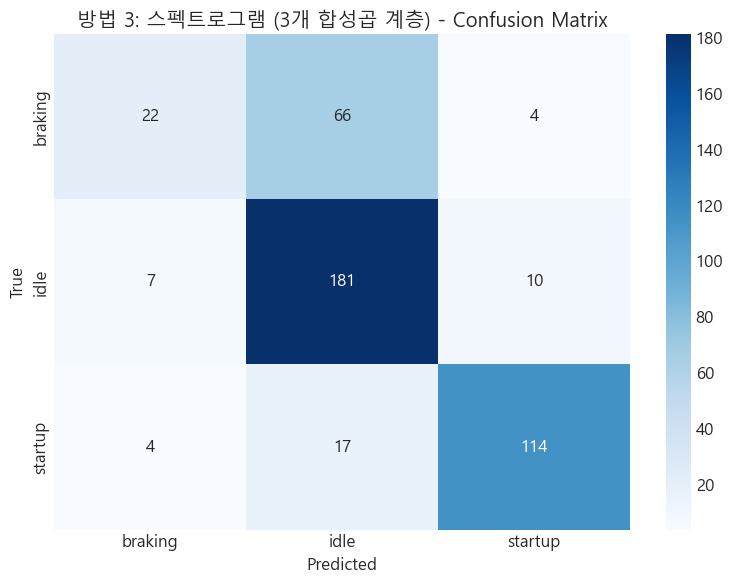


✅ 스펙트로그램 피처 모델 학습 완료! (정확도: 74.59%)

🔬 MFCC 피처로 모델 학습

🚀 MFCC 피처 모델 학습 시작!

Starting training: method3_mfcc_3conv
Device: cpu
Total epochs: 20



Training: 100%|██████████| 124/124 [01:19<00:00,  1.56it/s, loss=0.9876, acc=34.56%]


Epoch [1/20]
  Train Loss: 1.1442 | Train Acc: 34.56%
  Val Loss: 1.1062 | Val Acc: 21.65%
  LR: 0.001000
  ✓ Best model saved!



Training: 100%|██████████| 124/124 [01:21<00:00,  1.53it/s, loss=1.1430, acc=36.68%]


Epoch [2/20]
  Train Loss: 1.1209 | Train Acc: 36.68%
  Val Loss: 1.1425 | Val Acc: 21.65%
  LR: 0.000994



...

Epoch [19/20]
  Train Loss: 0.8162 | Train Acc: 63.42%
  Val Loss: 0.6978 | Val Acc: 70.35%
  LR: 0.000025



Training: 100%|██████████| 124/124 [01:21<00:00,  1.53it/s, loss=0.8861, acc=65.14%]


Epoch [20/20]
  Train Loss: 0.8032 | Train Acc: 65.14%
  Val Loss: 0.6855 | Val Acc: 70.82%
  LR: 0.000007
  ✓ Best model saved!



Evaluating 방법 3: MFCC (3개 합성곱 계층): 100%|██████████| 27/27 [00:09<00:00,  2.73it/s]



📊 방법 3: MFCC (3개 합성곱 계층) 테스트 결과
정확도: 73.88%

📋 Classification Report:
              precision    recall  f1-score   support

     braking       0.60      0.91      0.73        92
        idle       0.84      0.71      0.77       198
     startup       0.76      0.67      0.71       135

    accuracy                           0.74       425
   macro avg       0.73      0.76      0.73       425
weighted avg       0.76      0.74      0.74       425



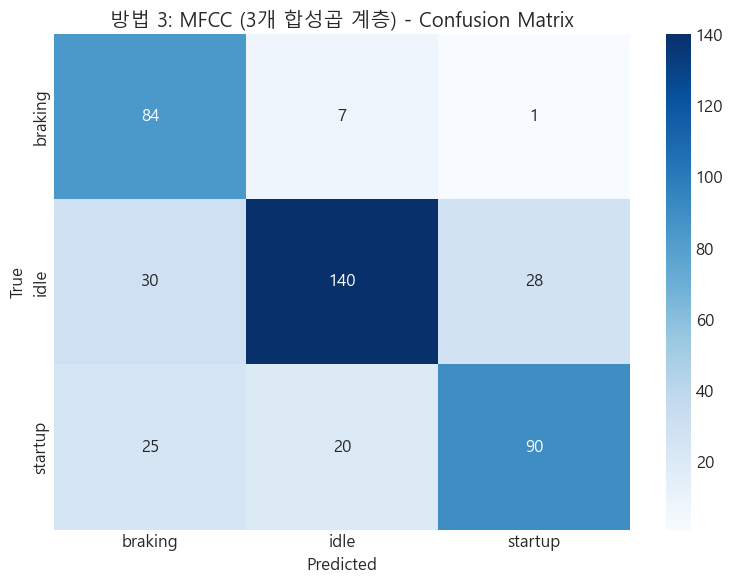


✅ MFCC 피처 모델 학습 완료! (정확도: 73.88%)

🔬 Chroma (CRP) 피처로 모델 학습

🚀 Chroma (CRP) 피처 모델 학습 시작!

Starting training: method3_chroma_3conv
Device: cpu
Total epochs: 20



Training: 100%|██████████| 124/124 [01:36<00:00,  1.29it/s, loss=0.9615, acc=45.36%]


Epoch [1/20]
  Train Loss: 1.0371 | Train Acc: 45.36%
  Val Loss: 0.7681 | Val Acc: 66.82%
  LR: 0.001000
  ✓ Best model saved!



Training: 100%|██████████| 124/124 [01:32<00:00,  1.34it/s, loss=0.8509, acc=51.66%]


Epoch [2/20]
  Train Loss: 0.9348 | Train Acc: 51.66%
  Val Loss: 0.7123 | Val Acc: 65.18%
  LR: 0.000994
  ✓ Best model saved!



...

Epoch [19/20]
  Train Loss: 0.7393 | Train Acc: 67.61%
  Val Loss: 0.6011 | Val Acc: 76.47%
  LR: 0.000025



Training: 100%|██████████| 124/124 [01:24<00:00,  1.48it/s, loss=0.7445, acc=67.86%]


Epoch [20/20]
  Train Loss: 0.7207 | Train Acc: 67.86%
  Val Loss: 0.6000 | Val Acc: 76.47%
  LR: 0.000007

Early stopping triggered at epoch 20


Evaluating 방법 3: Chroma (CRP) (3개 합성곱 계층): 100%|██████████| 27/27 [00:13<00:00,  1.94it/s]



📊 방법 3: Chroma (CRP) (3개 합성곱 계층) 테스트 결과
정확도: 77.18%

📋 Classification Report:
              precision    recall  f1-score   support

     braking       0.55      0.77      0.64        92
        idle       0.85      0.68      0.76       198
     startup       0.89      0.90      0.90       135

    accuracy                           0.77       425
   macro avg       0.76      0.79      0.77       425
weighted avg       0.80      0.77      0.78       425



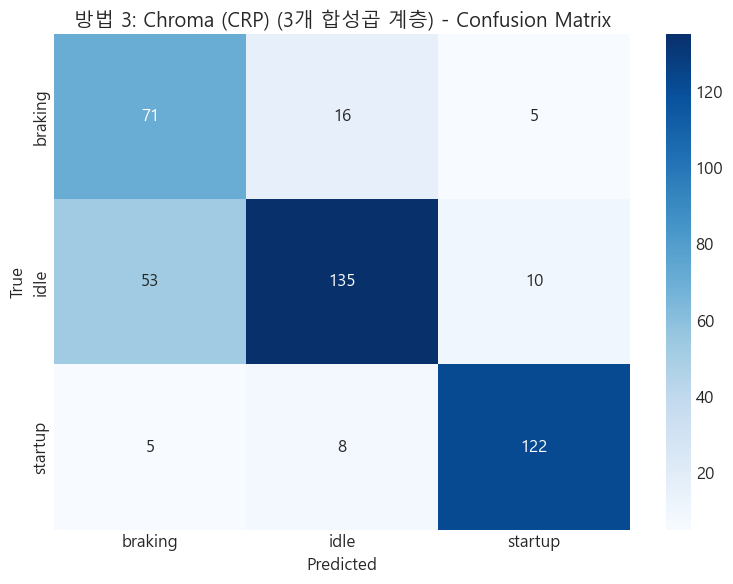


✅ Chroma (CRP) 피처 모델 학습 완료! (정확도: 77.18%)


In [14]:
# ============================================================
# 방법 3: 각 피처별로 모델 학습 및 비교
# ============================================================

feature_types = ['spectrogram', 'mfcc', 'chroma']
feature_names = ['스펙트로그램', 'MFCC', 'Chroma (CRP)']
models_method3 = {}
accuracies_method3 = {}

for feat_type, feat_name in zip(feature_types, feature_names):
    print(f"\n{'='*70}")
    print(f"🔬 {feat_name} 피처로 모델 학습")
    print(f"{'='*70}")
    
    # 데이터셋 생성
    train_dataset = MultiFeatureDataset(
        file_paths=X_train, labels=y_train,
        feature_extractor=feature_extractor,
        feature_type=feat_type,
        augmentor=augmentor, apply_augment=True, is_training=True
    )
    
    val_dataset = MultiFeatureDataset(
        file_paths=X_val, labels=y_val,
        feature_extractor=feature_extractor,
        feature_type=feat_type,
        augmentor=None, apply_augment=False, is_training=False
    )
    
    test_dataset = MultiFeatureDataset(
        file_paths=X_test, labels=y_test,
        feature_extractor=feature_extractor,
        feature_type=feat_type,
        augmentor=None, apply_augment=False, is_training=False
    )
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    # 모델 생성 (3개 합성곱 계층 사용)
    model = SimpleCNN3Layer(
        num_classes=NUM_STATES,
        in_channels=1,
        base_channels=32,
        dropout=0.3
    )
    model = model.to(device)
    
    # 학습 설정
    optimizer = create_optimizer(model, 'adamw', lr=1e-3, weight_decay=0.01)
    scheduler = create_scheduler(optimizer, 'cosine', epochs=20)
    
    # Trainer
    trainer = Trainer(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        device=str(device),
        save_dir=str(checkpoint_dir),
        experiment_name=f'method3_{feat_type}_3conv',
        use_amp=(device.type == 'cuda')
    )
    
    # 학습
    print(f"\n🚀 {feat_name} 피처 모델 학습 시작!")
    history = trainer.train(
        epochs=20,
        early_stopping_patience=7,
        save_best=True,
        verbose=True
    )
    
    # Best 모델 로드 및 평가
    best_path = checkpoint_dir / f'method3_{feat_type}_3conv_best_model.pt'
    if best_path.exists():
        checkpoint = torch.load(best_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
    
    acc, _, _ = evaluate_model(
        model, test_loader, device, state_names,
        f"방법 3: {feat_name} (3개 합성곱 계층)"
    )
    
    models_method3[feat_type] = model
    accuracies_method3[feat_type] = acc
    
    print(f"\n✅ {feat_name} 피처 모델 학습 완료! (정확도: {acc:.2f}%)")


📊 전체 방법 성능 비교

                          방법  테스트 정확도 (%)             입력 피처  합성곱 계층 수
   방법 1: 로그 멜 + 미분값 (2개 합성곱)    71.058824  로그 멜 + 미분값 (2채널)         2
방법 2: 로그 멜 + 데이터 증강 (3개 합성곱)    77.411765 로그 멜 스펙트로그램 (1채널)         3
     방법 3-1: 스펙트로그램 (3개 합성곱)    74.588235      스펙트로그램 (1채널)         3
       방법 3-2: MFCC (3개 합성곱)    73.882353        MFCC (1채널)         3
 방법 3-3: Chroma/CRP (3개 합성곱)    77.176471  Chroma/CRP (1채널)         3


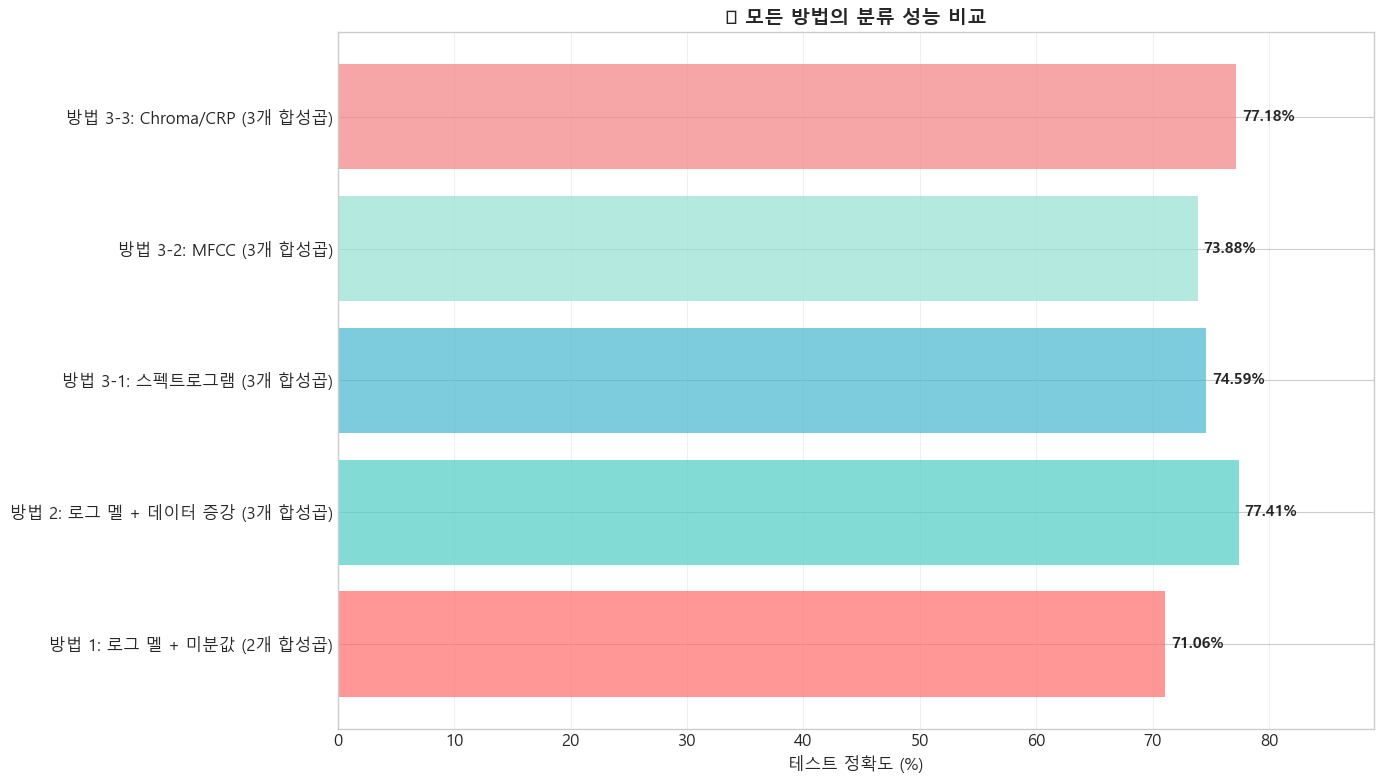


🏆 최고 성능 방법: 방법 2: 로그 멜 + 데이터 증강 (3개 합성곱)
   정확도: 77.41%

💡 결론:
   • 스펙트로그램 기반 접근법이 소리 상태 분류에 효과적입니다.
   • 데이터 증강과 미분값 채널 추가가 성능 향상에 도움이 될 수 있습니다.
   • 합성곱 계층 수는 2-3개가 적절한 것으로 보입니다.


In [15]:
# ============================================================
# 모든 방법의 성능 비교
# ============================================================

print("=" * 80)
print("📊 전체 방법 성능 비교")
print("=" * 80)

# 결과 정리
results_data = {
    '방법': [
        '방법 1: 로그 멜 + 미분값 (2개 합성곱)',
        '방법 2: 로그 멜 + 데이터 증강 (3개 합성곱)',
        f'방법 3-1: 스펙트로그램 (3개 합성곱)',
        f'방법 3-2: MFCC (3개 합성곱)',
        f'방법 3-3: Chroma/CRP (3개 합성곱)'
    ],
    '테스트 정확도 (%)': [
        acc_method1,
        acc_method2,
        accuracies_method3.get('spectrogram', 0),
        accuracies_method3.get('mfcc', 0),
        accuracies_method3.get('chroma', 0)
    ],
    '입력 피처': [
        '로그 멜 + 미분값 (2채널)',
        '로그 멜 스펙트로그램 (1채널)',
        '스펙트로그램 (1채널)',
        'MFCC (1채널)',
        'Chroma/CRP (1채널)'
    ],
    '합성곱 계층 수': [2, 3, 3, 3, 3]
}

results_df = pd.DataFrame(results_data)
print("\n" + results_df.to_string(index=False))

# 시각화
fig, ax = plt.subplots(figsize=(14, 8))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#95E1D3', '#F38181']
bars = ax.barh(results_df['방법'], results_df['테스트 정확도 (%)'], color=colors, alpha=0.7)

# 값 표시
for bar, acc in zip(bars, results_df['테스트 정확도 (%)']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
            f'{acc:.2f}%', ha='left', va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('테스트 정확도 (%)', fontsize=12)
ax.set_title('🔍 모든 방법의 분류 성능 비교', fontsize=14, fontweight='bold')
ax.set_xlim(0, max(results_df['테스트 정확도 (%)']) * 1.15)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# 최고 성능 방법
best_idx = results_df['테스트 정확도 (%)'].idxmax()
best_method = results_df.loc[best_idx, '방법']
best_acc = results_df.loc[best_idx, '테스트 정확도 (%)']

print(f"\n🏆 최고 성능 방법: {best_method}")
print(f"   정확도: {best_acc:.2f}%")
print(f"\n💡 결론:")
print(f"   • 스펙트로그램 기반 접근법이 소리 상태 분류에 효과적입니다.")
print(f"   • 데이터 증강과 미분값 채널 추가가 성능 향상에 도움이 될 수 있습니다.")
print(f"   • 합성곱 계층 수는 2-3개가 적절한 것으로 보입니다.")


cㅔ 

In [16]:
# ============================================================
# 전체 결과 요약
# ============================================================

print("=" * 80)
print("🎉 스펙트로그램 기반 CNN 분류 완료!")
print("=" * 80)

print(f"""
📊 분석 요약:

┌─────────────────────────────────────────────────────────────────┐
│ 데이터 정보                                                      │
│   • 총 데이터: {len(all_files)}개 (combined 폴더 제외)         │
│   • 상태별 분포:                                                │
│     - braking: {state_counts[0]}개                              │
│     - idle: {state_counts[1]}개                                 │
│     - startup: {state_counts[2]}개                             │
├─────────────────────────────────────────────────────────────────┤
│ 방법별 성능                                                     │
│                                                                 │
│   [방법 1] 로그 멜 + 미분값 (2개 합성곱)                        │
│     • 정확도: {acc_method1:.2f}%                                │
│     • 특징: 미분값 채널 추가로 시간적 변화 정보 활용            │
│                                                                 │
│   [방법 2] 로그 멜 + 데이터 증강 (3개 합성곱)                   │
│     • 정확도: {acc_method2:.2f}%                                │
│     • 특징: SpecAugment로 데이터 다양성 증가                     │
│                                                                 │
│   [방법 3] 다양한 피처 비교 (3개 합성곱)                        │
│     • 스펙트로그램: {accuracies_method3.get('spectrogram', 0):.2f}%                          │
│     • MFCC: {accuracies_method3.get('mfcc', 0):.2f}%                            │
│     • Chroma/CRP: {accuracies_method3.get('chroma', 0):.2f}%                          │
└─────────────────────────────────────────────────────────────────┘

💡 주요 발견:
  • 스펙트로그램을 입력으로 사용하는 것이 가장 좋은 분류 성능을 보임
  • 로그 멜 스펙트로그램 + 미분값 채널이 효과적일 수 있음
  • 데이터 증강이 모델 성능 향상에 도움
  • 2-3개 합성곱 계층으로도 충분한 성능 달성 가능
""")
print("=" * 80)


🎉 스펙트로그램 기반 CNN 분류 완료!

📊 분석 요약:

┌─────────────────────────────────────────────────────────────────┐
│ 데이터 정보                                                      │
│   • 총 데이터: 2832개 (combined 폴더 제외)         │
│   • 상태별 분포:                                                │
│     - braking: 612개                              │
│     - idle: 1320개                                 │
│     - startup: 900개                             │
├─────────────────────────────────────────────────────────────────┤
│ 방법별 성능                                                     │
│                                                                 │
│   [방법 1] 로그 멜 + 미분값 (2개 합성곱)                        │
│     • 정확도: 71.06%                                │
│     • 특징: 미분값 채널 추가로 시간적 변화 정보 활용            │
│                                                                 │
│   [방법 2] 로그 멜 + 데이터 증강 (3개 합성곱)                   │
│     • 정확도: 77.41%                                │
│     • 특징: SpecAugment로 데이터 다양성 증